# **K-Nearest Neighbours with KD-Tree from Scratch using NumP**y

**Dataset:** MNIST Handwritten Digits + 2D Synthetic Dataset  
**Tools:** NumPy only — no sklearn, no ML libraries


##**Why am I using KD Tree here?**

Because normal K Nearest Neighbours is a very slow algorithm which grows at O(N) but with KD Tree, this growth rate decreases to O(logN) which is much much faster than before.

In [1]:
import numpy as np
import heapq
import time
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from collections import Counter
from tensorflow.keras.datasets import mnist

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
np.random.seed(42)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train : (5000, 784)  |  Test : (1000, 784)
Classes : [0 1 2 3 4 5 6 7 8 9]


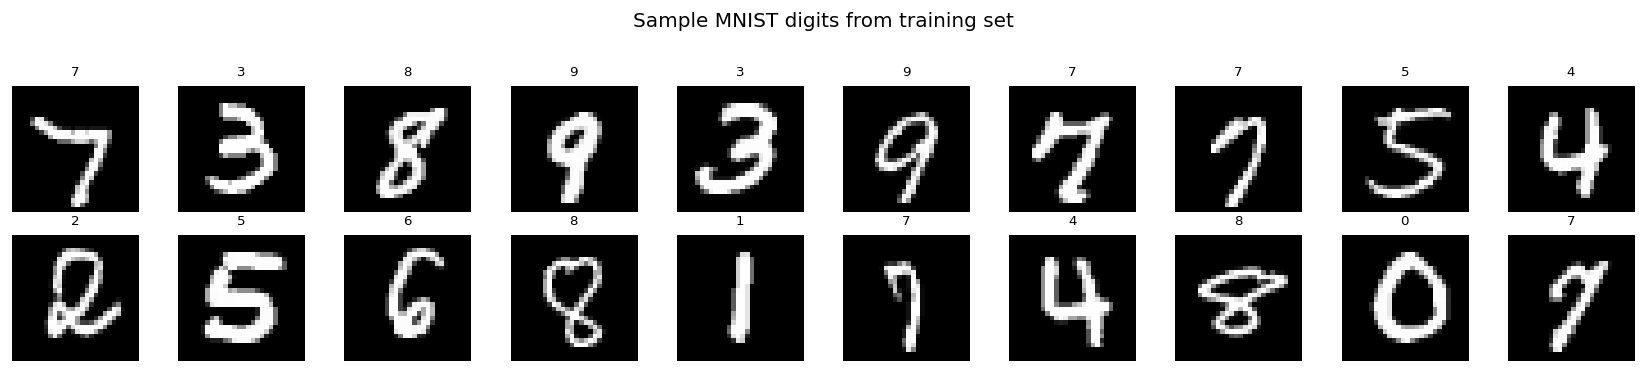

In [2]:
(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()

X_train = X_train_raw.reshape(len(X_train_raw), -1).astype(np.float32) / 255.0
X_test  = X_test_raw.reshape(len(X_test_raw),  -1).astype(np.float32) / 255.0

N_TRAIN, N_TEST = 5000, 1000
idx_tr = np.random.choice(len(X_train), N_TRAIN, replace=False)
idx_te = np.random.choice(len(X_test),  N_TEST,  replace=False)
X_tr, y_tr = X_train[idx_tr], y_train[idx_tr]
X_te, y_te = X_test[idx_te],  y_test[idx_te]

print(f'Train : {X_tr.shape}  |  Test : {X_te.shape}')
print(f'Classes : {np.unique(y_tr)}')

fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_tr[i].reshape(28, 28), cmap='gray')
    ax.set_title(str(y_tr[i]), fontsize=8)
    ax.axis('off')
plt.suptitle('Sample MNIST digits from training set', y=1.02)
plt.tight_layout()
plt.show()

### Shared voting function

Both KNN implementations use the same `_majority_vote` so predictions are guaranteed to be identical — ties in vote count are broken by choosing the class with the smallest distance to its nearest member.

In [3]:
def _majority_vote(labels, dists):
    counts    = Counter(labels)
    max_count = max(counts.values())
    candidates = [lbl for lbl, cnt in counts.items() if cnt == max_count]
    if len(candidates) == 1:
        return candidates[0]
    # tie-break: class whose nearest neighbour is closest
    return min(candidates, key=lambda lbl: dists[labels == lbl].min())

<a id='naive'></a>
## Naive KNN (Brute Force, O(n))

In [4]:
class NaiveKNN:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict_single(self, x):
        diff   = self.X_train - x
        dists  = np.sqrt((diff * diff).sum(axis=1))
        order  = np.argsort(dists)[:self.k]
        return _majority_vote(self.y_train[order], dists[order])

    def predict(self, X):
        return np.array([self.predict_single(x) for x in X])

In [5]:
naive_knn = NaiveKNN(k=5)
naive_knn.fit(X_tr, y_tr)

t0          = time.time()
naive_preds = naive_knn.predict(X_te)
naive_time  = time.time() - t0

naive_acc = np.mean(naive_preds == y_te)
print(f'Naive KNN  |  K=5  |  Accuracy: {naive_acc*100:.2f}%  |  Time: {naive_time:.2f}s')

Naive KNN  |  K=5  |  Accuracy: 94.20%  |  Time: 7.56s


<a id='kdtree'></a>
## KD-Tree KNN (O(log n))

Each tree node stores its **original training index** (`orig_idx`). The heap key is `(-dist^2, orig_idx, label)` — using `orig_idx` as a tie-breaker means equidistant candidates are evicted in the same order that `np.argsort` would rank them, guaranteeing identical predictions to the naive method.

In [6]:
class KDNode:
    __slots__ = ('point', 'label', 'orig_idx', 'axis', 'split_val', 'left', 'right')

    def __init__(self, point, label, orig_idx, axis, split_val, left=None, right=None):
        self.point, self.label, self.orig_idx = point, label, orig_idx
        self.axis,  self.split_val            = axis,  split_val
        self.left,  self.right                = left,  right


class KDTree:
    def __init__(self):
        self.root = None

    def fit(self, X, y):
        self.root = self._build(X, y, np.arange(len(X)))

    def _build(self, X, y, indices):
        if len(indices) == 0:
            return None
        axis  = int(np.argmax(X[indices].var(axis=0)))
        order = indices[np.argsort(X[indices, axis], kind='stable')]
        mid   = len(order) // 2
        idx   = order[mid]
        return KDNode(
            point=X[idx], label=y[idx], orig_idx=int(idx),
            axis=axis, split_val=X[idx, axis],
            left=self._build(X, y, order[:mid]),
            right=self._build(X, y, order[mid + 1:]),
        )

    def _search(self, node, q, k, heap):
        if node is None:
            return
        diff  = q - node.point
        d2    = float(diff @ diff)
        entry = (-d2, node.orig_idx, node.label)
        if len(heap) < k:
            heapq.heappush(heap, entry)
        elif (-d2, node.orig_idx) > (heap[0][0], heap[0][1]):
            heapq.heapreplace(heap, entry)
        gap       = q[node.axis] - node.split_val
        near, far = (node.left, node.right) if gap <= 0 else (node.right, node.left)
        self._search(near, q, k, heap)
        worst = -heap[0][0] if len(heap) == k else float('inf')
        if gap * gap < worst:
            self._search(far, q, k, heap)

    def query(self, q, k):
        heap = []
        self._search(self.root, q, k, heap)
        labels = np.array([lbl           for _, _, lbl in heap])
        dists  = np.array([np.sqrt(-nd2) for nd2, _, _ in heap])
        return labels, dists


class KDTreeKNN:
    def __init__(self, k=5):
        self.k    = k
        self.tree = KDTree()

    def fit(self, X, y):
        self.tree.fit(X, y)

    def predict_single(self, x):
        labels, dists = self.tree.query(x, self.k)
        return _majority_vote(labels, dists)

    def predict(self, X):
        return np.array([self.predict_single(x) for x in X])

In [7]:
print('Building KD-Tree...')
t0 = time.time()
kd_knn = KDTreeKNN(k=5)
kd_knn.fit(X_tr, y_tr)
print(f'Build time : {time.time() - t0:.2f}s')

t0       = time.time()
kd_preds = kd_knn.predict(X_te)
kd_time  = time.time() - t0

kd_acc = np.mean(kd_preds == y_te)
print(f'KD-Tree KNN  |  K=5  |  Accuracy: {kd_acc*100:.2f}%  |  Time: {kd_time:.2f}s')
print(f'Predictions match naive KNN : {np.all(kd_preds == naive_preds)}')

Building KD-Tree...
Build time : 0.47s
KD-Tree KNN  |  K=5  |  Accuracy: 94.20%  |  Time: 25.06s
Predictions match naive KNN : True


<a id='comparison'></a>
## Speed & Accuracy Comparison

### - Speed Benchmark — 2D Synthetic Data

KD-Tree's $O(\log n)$ advantage is only visible in **low dimensions** — in 2D the tree prunes almost all of the search space so very few nodes are visited. I generated a large 2D dataset here specifically to show the crossover. After the crossover point, KD-Tree query time grows much more slowly than brute force.

In [8]:
np.random.seed(1)
sizes       = [100, 250, 500, 1000, 2500, 5000, 10000, 25000]
N_Q         = 50
naive_times = []
kd_times    = []

X_2d_pool = np.random.randn(25000, 2).astype(np.float32)
y_2d_pool = np.random.randint(0, 5, 25000)
X_2d_q    = np.random.randn(N_Q, 2).astype(np.float32)

print(f'{"Size":>6}  {"Naive (s)":>10}  {"KD-Tree (s)":>12}  {"KD wins":>8}')
print('-' * 44)

for n in sizes:
    Xn, yn = X_2d_pool[:n], y_2d_pool[:n]

    nk = NaiveKNN(k=5)
    nk.fit(Xn, yn)
    t0 = time.time(); nk.predict(X_2d_q); nt = time.time() - t0
    naive_times.append(nt)

    kk = KDTreeKNN(k=5)
    kk.fit(Xn, yn)
    t0 = time.time(); kk.predict(X_2d_q); kt = time.time() - t0
    kd_times.append(kt)

    print(f'{n:>6}  {nt:>10.4f}  {kt:>12.4f}  {str(kt < nt):>8}')

  Size   Naive (s)   KD-Tree (s)   KD wins
--------------------------------------------
   100      0.0019        0.0046     False
   250      0.0017        0.0048     False
   500      0.0026        0.0053     False
  1000      0.0034        0.0057     False
  2500      0.0069        0.0066      True
  5000      0.0137        0.0064      True
 10000      0.0302        0.0070      True
 25000      0.0661        0.0071      True


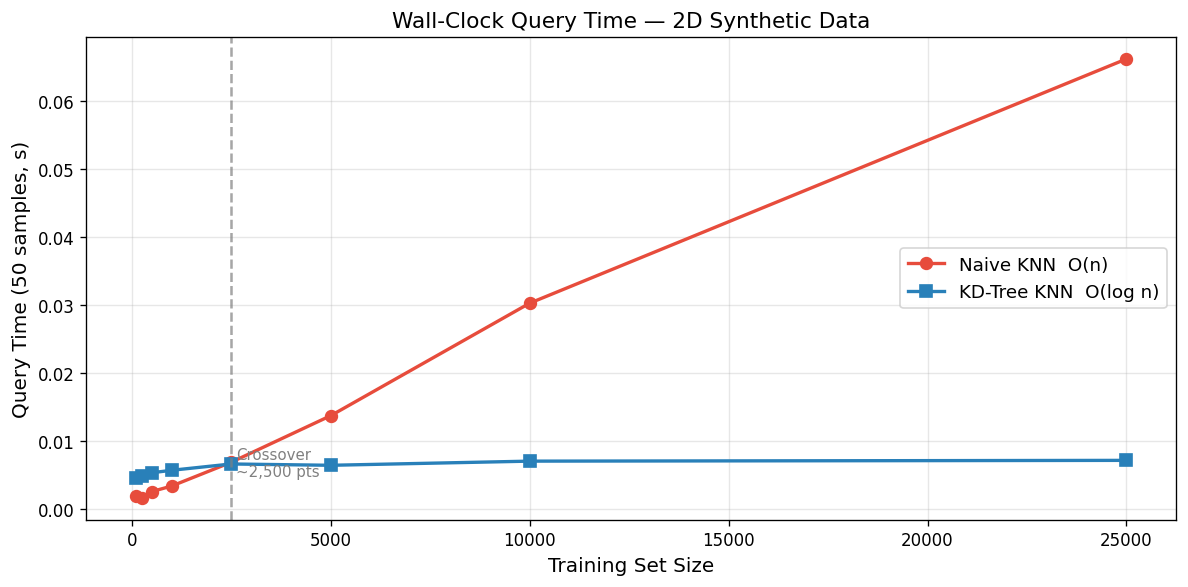

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(sizes, naive_times, 'o-', color='#e74c3c', lw=2, ms=7, label='Naive KNN  O(n)')
ax.plot(sizes, kd_times,   's-', color='#2980b9', lw=2, ms=7, label='KD-Tree KNN  O(log n)')

cross = next((i for i in range(len(sizes)) if kd_times[i] < naive_times[i]), None)
if cross is not None:
    cx = sizes[cross]
    cy = (naive_times[cross] + kd_times[cross]) / 2
    ax.axvline(cx, color='gray', ls='--', alpha=0.7)
    ax.text(cx * 1.05, cy, f'Crossover\n~{cx:,} pts', fontsize=9, color='gray', va='center')

ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel(f'Query Time ({N_Q} samples, s)', fontsize=12)
ax.set_title('Wall-Clock Query Time — 2D Synthetic Data', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Accuracy vs K

Both implementations must return identical predictions at every K. The two lines should overlap exactly.

In [10]:
k_vals = [1, 3, 5, 7, 9, 11]
naccs, kaccs = [], []

Xts, yts = X_tr[:1000], y_tr[:1000]
Xev, yev = X_te[:200],  y_te[:200]

print(f'{"K":>3}  {"Naive":>8}  {"KD-Tree":>10}  {"Match":>6}')
print('-' * 36)

for k in k_vals:
    nk = NaiveKNN(k=k);  nk.fit(Xts, yts); na = np.mean(nk.predict(Xev) == yev)
    kk = KDTreeKNN(k=k); kk.fit(Xts, yts); ka = np.mean(kk.predict(Xev) == yev)
    naccs.append(na); kaccs.append(ka)
    print(f'{k:>3}  {na*100:>7.2f}%  {ka*100:>9.2f}%  {"YES" if abs(na - ka) < 1e-9 else "NO":>6}')

  K     Naive     KD-Tree   Match
------------------------------------
  1    89.00%      89.00%     YES
  3    91.00%      91.00%     YES
  5    89.50%      89.50%     YES
  7    90.00%      90.00%     YES
  9    89.00%      89.00%     YES
 11    89.00%      89.00%     YES


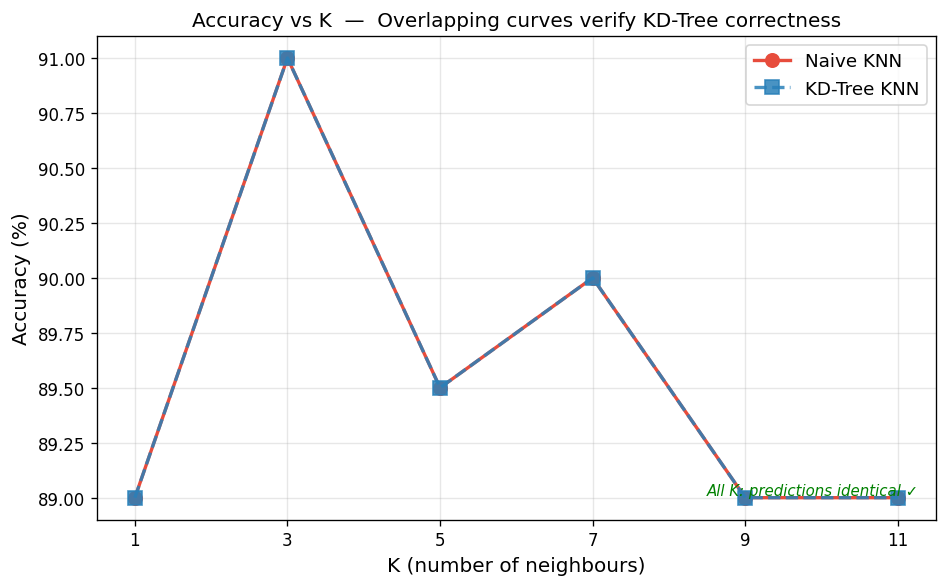

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(k_vals, [a * 100 for a in naccs], 'o-',  color='#e74c3c', lw=2, ms=8, label='Naive KNN')
ax.plot(k_vals, [a * 100 for a in kaccs], 's--', color='#2980b9', lw=2, ms=8,
        label='KD-Tree KNN', alpha=0.85)

all_match = all(abs(na - ka) < 1e-9 for na, ka in zip(naccs, kaccs))
status    = 'All K: predictions identical ✓' if all_match else 'Warning: mismatch detected'
color     = 'green' if all_match else 'red'

ax.set_xlabel('K (number of neighbours)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy vs K  —  Overlapping curves verify KD-Tree correctness', fontsize=12)
ax.set_xticks(k_vals)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.text(0.98, 0.05, status, transform=ax.transAxes,
        fontsize=9, ha='right', color=color, style='italic')
plt.tight_layout()
plt.show()

Voila! They overlap correctly at every point as visible above.

<a id='viz'></a>
## Decision Boundary on 2D Synthetic Dataset

In [12]:
np.random.seed(0)
means      = [[-2.0, -2.0], [2.0, -1.0], [0.0, 3.0]]
colors_cls = ['#e74c3c', '#2980b9', '#27ae60']

X_syn = np.vstack([np.random.randn(100, 2) + m for m in means])
y_syn = np.repeat([0, 1, 2], 100)
perm  = np.random.permutation(300)
X_syn, y_syn = X_syn[perm], y_syn[perm]

X_str, y_str = X_syn[:240], y_syn[:240]
X_ste, y_ste = X_syn[240:], y_syn[240:]
print(f'Synthetic  |  Train: {X_str.shape}  |  Test: {X_ste.shape}')

Synthetic  |  Train: (240, 2)  |  Test: (60, 2)


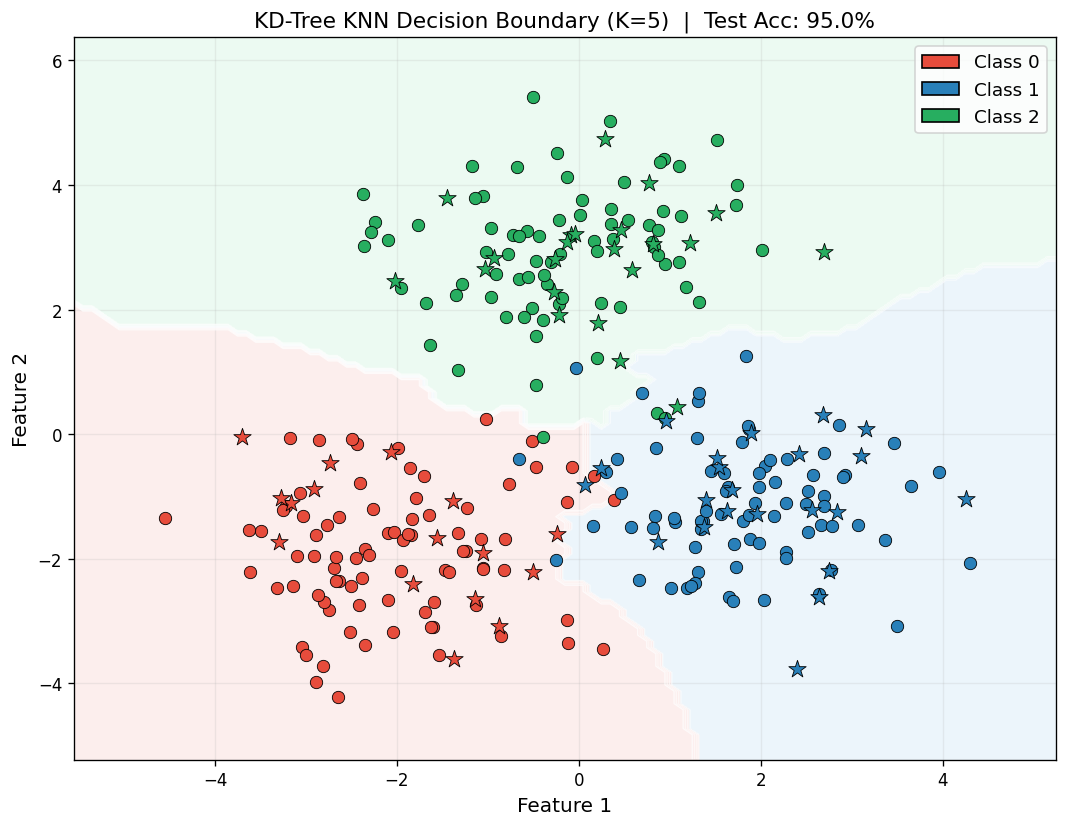

In [13]:
kd_syn = KDTreeKNN(k=5)
kd_syn.fit(X_str, y_str)

mg = 1.0
xx, yy = np.meshgrid(
    np.arange(X_syn[:, 0].min() - mg, X_syn[:, 0].max() + mg, 0.10),
    np.arange(X_syn[:, 1].min() - mg, X_syn[:, 1].max() + mg, 0.10)
)
Z = kd_syn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(xx, yy, Z, alpha=0.45,
            cmap=mcolors.ListedColormap(['#fadbd8', '#d6eaf8', '#d5f5e3']))
ax.contour(xx, yy, Z, colors='white', linewidths=0.8, alpha=0.7)

for c, col in zip([0, 1, 2], colors_cls):
    m = y_str == c
    ax.scatter(X_str[m, 0], X_str[m, 1], c=col, edgecolors='k', lw=0.5, s=55, zorder=3)
    m = y_ste == c
    ax.scatter(X_ste[m, 0], X_ste[m, 1], c=col, marker='*', edgecolors='k', lw=0.5, s=120, zorder=4)

patches = [mpatches.Patch(facecolor=c, edgecolor='k', label=f'Class {i}')
           for i, c in enumerate(colors_cls)]
ax.legend(handles=patches, fontsize=11)

acc = np.mean(kd_syn.predict(X_ste) == y_ste)
ax.set_title(f'KD-Tree KNN Decision Boundary (K=5)  |  Test Acc: {acc*100:.1f}%', fontsize=13)
ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()